In [111]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import torchvision.datasets
import torchvision.transforms

In [112]:
pets_path_train = './OxfordPets/train'
pets_path_test = './OxfordPets/test'
pets_train_orig = torchvision.datasets.OxfordIIITPet(root=pets_path_train, split='trainval', target_types='category', download=True)
pets_test_orig = torchvision.datasets.OxfordIIITPet(root=pets_path_test, split='test', target_types='category', download=True)

In [113]:
class_names = pets_train_orig.classes

In [114]:
pets_train_orig, pets_test_orig

(Dataset OxfordIIITPet
     Number of datapoints: 3680
     Root location: ./OxfordPets/train,
 Dataset OxfordIIITPet
     Number of datapoints: 3669
     Root location: ./OxfordPets/test)

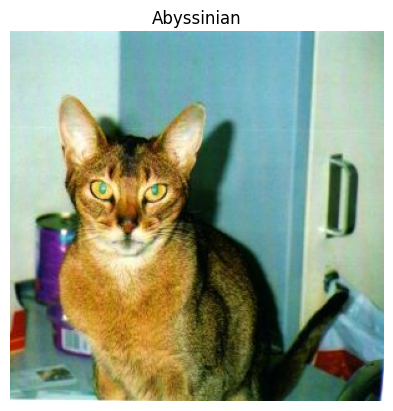

In [115]:
(train_pets_input, train_pets_target) = pets_train_orig[20]
plt.imshow(train_pets_input)
# plt.imshow(train_pets_input.permute(1,2,0).numpy())
plt.title(class_names[train_pets_target])
plt.axis('off')
plt.show()

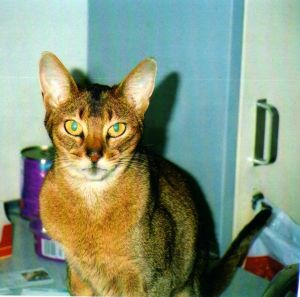

In [116]:
train_pets_input

In [117]:
train_pets_target

0

In [118]:
len(pets_train_orig), len(pets_test_orig)

(3680, 3669)

In [119]:
# def collate_fn(batch):
#     return {
#         'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
#         'labels': torch.tensor([x['labels'] for x in batch])
#     }

In [120]:
# Create a dataset wrapper that allows us to perform custom image augmentations
# on both the target and label (segmentation mask) images.
#
# These custom image augmentations are needed since we want to perform
# transforms such as:
# 1. Random horizontal flip
# 2. Image resize
#
# and these operations need to be applied consistently to both the input
# image as well as the segmentation mask.
class OxfordIIITPetsAugmented(torchvision.datasets.OxfordIIITPet):
    def __init__(
        self,
        root: str,
        split: str,
        # target_types="segmentation",
        target_types="category",
        download=False,
        pre_transform=None,
        post_transform=None,
        pre_target_transform=None,
        post_target_transform=None,
        common_transform=None,
    ):
        super().__init__(
            root=root,
            split=split,
            target_types=target_types,
            download=download,
            transform=pre_transform,
            # target_transform=pre_target_transform,
        )
        self.post_transform = post_transform
        # self.post_target_transform = post_target_transform
        self.common_transform = common_transform

    def __len__(self):
        return super().__len__()

    def __getitem__(self, idx):
        (input, target) = super().__getitem__(idx)
        
        # Common transforms are performed on both the input and the labels
        # by creating a 4 channel image and running the transform on both.
        # Then the segmentation mask (4th channel) is separated out.
        if self.common_transform is not None:
            # both = torch.cat([input, target], dim=0)
            # both = self.common_transform(both)
            # (input, target) = torch.split(both, 3, dim=0)
            input = self.common_transform(input)
        # end if
        
        if self.post_transform is not None:
            input = self.post_transform(input)
        # if self.post_target_transform is not None:
        #     target = self.post_target_transform(target)

        return (input, target)

In [121]:
import torchvision.transforms as T

In [122]:
def args_to_dict(**kwargs):
    return kwargs

transform_dict = args_to_dict(
    pre_transform=T.ToTensor(),
    pre_target_transform=T.ToTensor(),
    common_transform=T.Compose([
        # ToDevice(get_device()),
        # T.Resize((128, 128), interpolation=T.InterpolationMode.NEAREST),
        T.Resize((224, 224), interpolation=T.InterpolationMode.NEAREST),
        # Random Horizontal Flip as data augmentation.
        T.RandomHorizontalFlip(p=0.5),
    ]),
    post_transform=T.Compose([
        # Color Jitter as data augmentation.
        T.ColorJitter(contrast=0.3),
    ]),
    # post_target_transform=T.Compose([
    #     # T.Lambda(tensor_trimap),
    # ]),
)

In [123]:
pets_train = OxfordIIITPetsAugmented(
    root=pets_path_train,
    split="trainval",
    # target_types="segmentation",
    target_types="category",
    download=False,
    **transform_dict,
)

In [124]:
pets_test = OxfordIIITPetsAugmented(
    root=pets_path_test,
    split="test",
    # target_types="segmentation",
    target_types="category",
    download=False,
    **transform_dict,
)

In [125]:
pets_train, pets_test

(Dataset OxfordIIITPetsAugmented
     Number of datapoints: 3680
     Root location: ./OxfordPets/train
     StandardTransform
 Transform: ToTensor(),
 Dataset OxfordIIITPetsAugmented
     Number of datapoints: 3669
     Root location: ./OxfordPets/test
     StandardTransform
 Transform: ToTensor())

In [126]:
pets_train_loader = torch.utils.data.DataLoader(
    pets_train,
    # batch_size=64,
    batch_size=16,
    shuffle=True,
)

In [127]:
pets_test_loader = torch.utils.data.DataLoader(
    pets_test,
    batch_size=21,
    shuffle=True,
)

In [128]:
(train_pets_inputs, train_pets_targets) = next(iter(pets_train_loader))

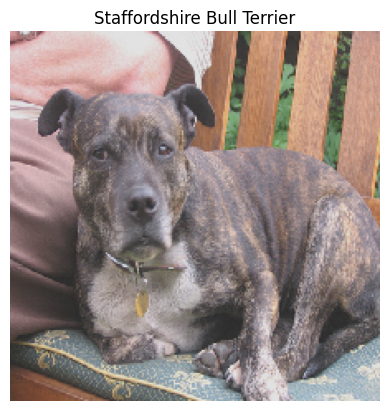

In [129]:
plt.imshow(train_pets_inputs[0].permute(1,2,0).numpy())
plt.axis('off')
plt.title(class_names[train_pets_targets[0]])
plt.show()

In [130]:
train_pets_targets

tensor([34, 16, 15, 35,  0, 12, 33, 26, 18,  4, 13, 36, 35,  6,  7, 15])

In [131]:
def show_images(input_tensor, title=''):
    image = input_tensor.permute(1,2,0).numpy()
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
    plt.show()
    plt.pause(0.01)

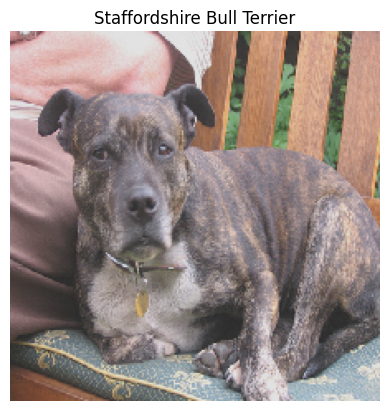

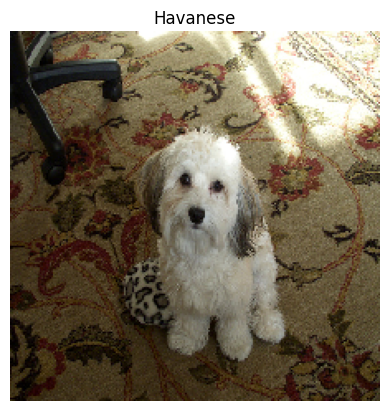

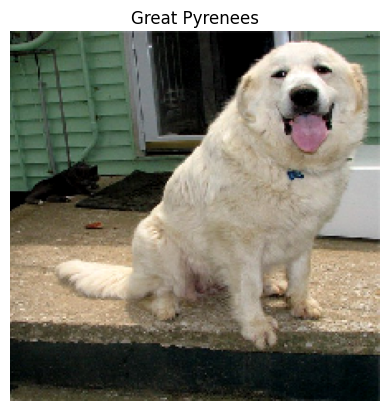

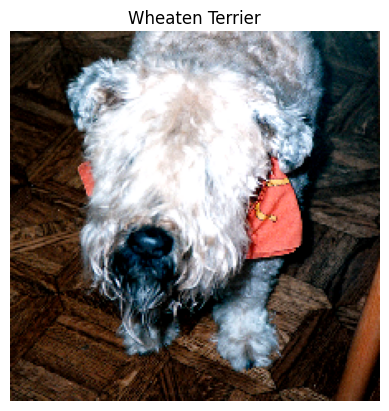

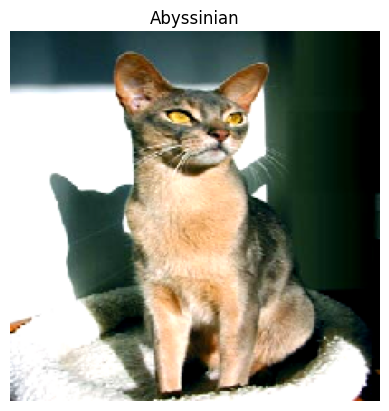

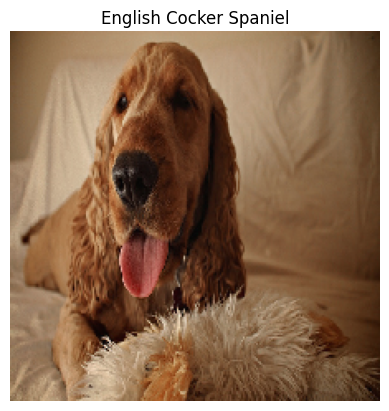

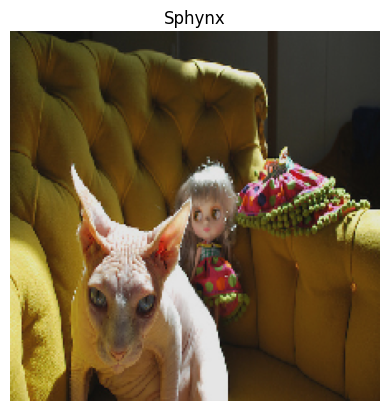

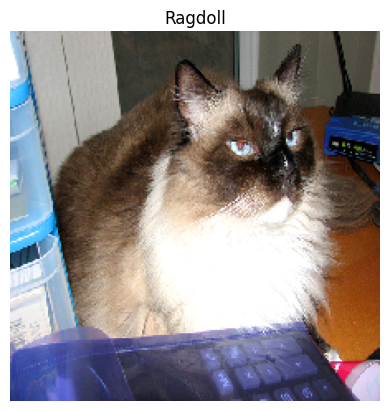

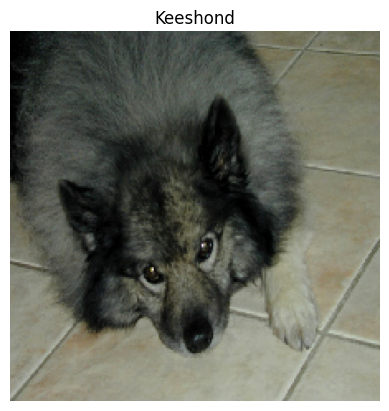

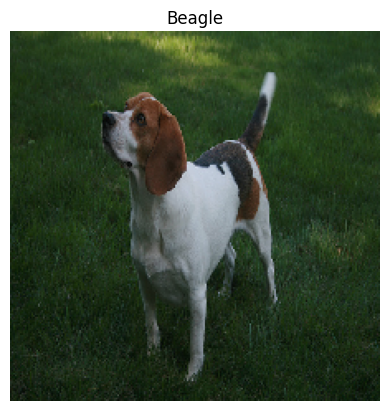

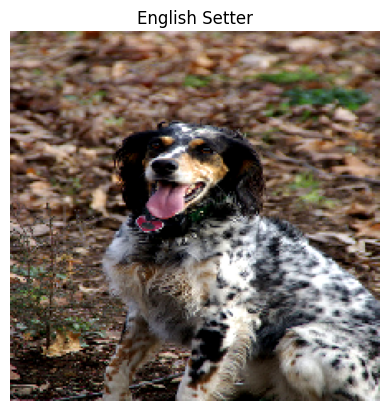

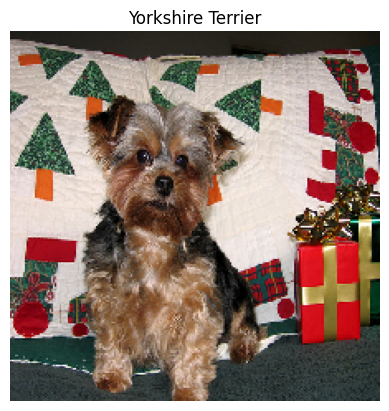

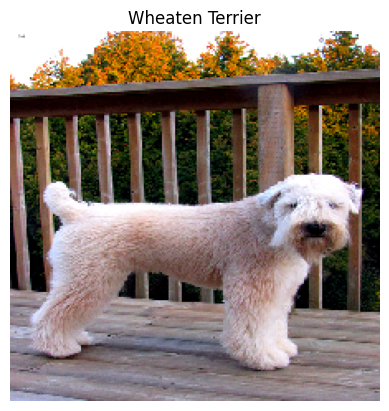

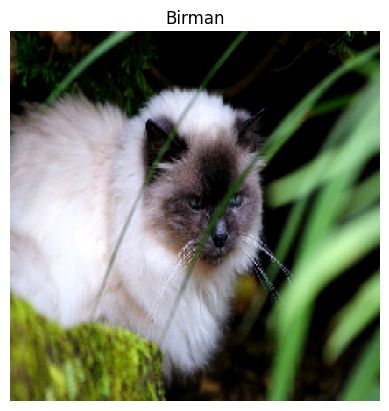

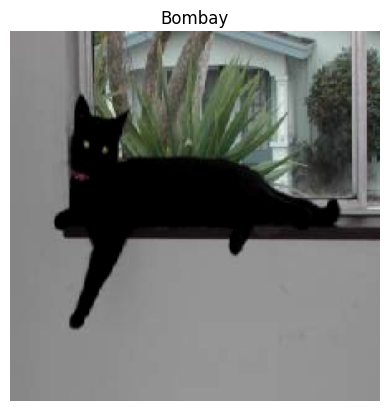

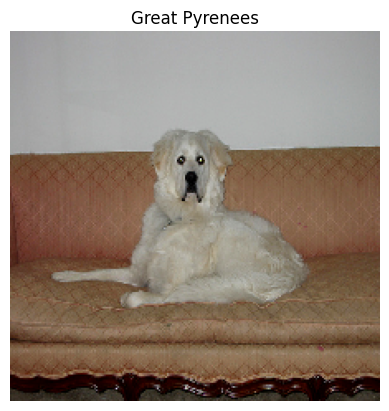

In [132]:
for i in range(len(train_pets_inputs)):
    show_images(train_pets_inputs[i], title=class_names[train_pets_targets[i]])